In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

listings = pd.read_csv("../data/processed/listings_features.csv")

# Cast boolean columns to int (they may have been read back as True/False strings)
bool_cols = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified',
             'instant_bookable', 'has_reviews']
for col in bool_cols:
    if col in listings.columns:
        listings[col] = listings[col].map({True: 1, False: 0,
                                           'True': 1, 'False': 0,
                                           1: 1, 0: 0}).fillna(0).astype(int)

print("Loaded shape:", listings.shape)
print(listings.dtypes.value_counts())

Loaded shape: (44304, 51)
int64      26
float64    20
str         5
Name: count, dtype: int64


In [3]:
cols_to_drop = [
    # Constant after imputation — zero predictive value
    'has_availability',

    # Numeric IDs for what are actually categories — already have region_name/parent_name
    'region_id',
    'region_parent_id',

    # Redundant availability windows — keep only availability_365
    'availability_30',
    'availability_60',
    'availability_90',

    # Redundant host listing sub-counts — keep calculated_host_listings_count
    'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms',

    # Redundant rolling review windows — keep number_of_reviews + reviews_per_month
    'number_of_reviews_l30d',
    'number_of_reviews_ltm',
    'number_of_reviews_ly',
]

cols_to_drop = [c for c in cols_to_drop if c in listings.columns]
listings = listings.drop(columns=cols_to_drop)

print("Shape after dropping redundant columns:", listings.shape)
print("Remaining columns:\n", listings.columns.tolist())

Shape after dropping redundant columns: (44304, 39)
Remaining columns:
 ['host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_listings_count', 'host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'latitude', 'longitude', 'room_type', 'accommodates', 'bedrooms', 'beds', 'price', 'minimum_nights', 'maximum_nights', 'availability_365', 'number_of_reviews', 'availability_eoy', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'instant_bookable', 'calculated_host_listings_count', 'region_name', 'region_parent_name', 'reviews_per_month', 'bathrooms_num', 'amenities_count', 'host_verifications_count', 'has_reviews', 'host_tenure_days', 'review_recency_days', 'property_type_grouped']


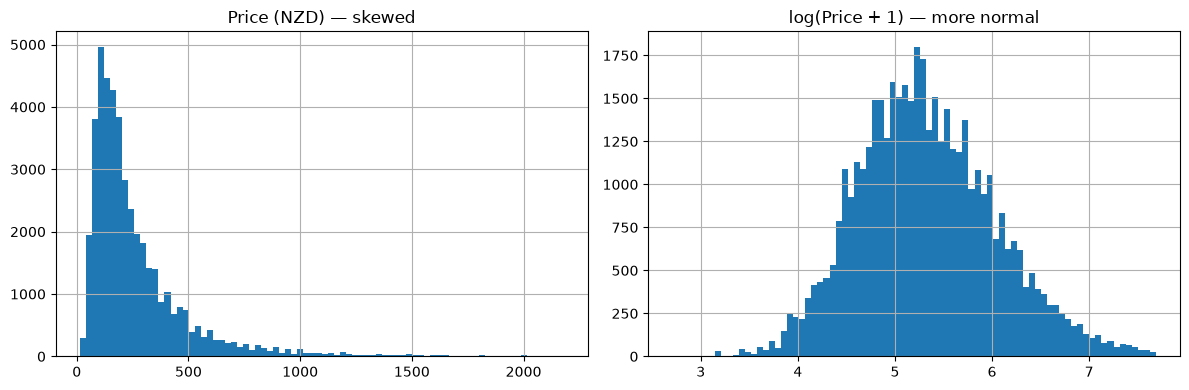

In [4]:
listings['log_price'] = np.log1p(listings['price'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
listings['price'].hist(bins=80, ax=axes[0])
axes[0].set_title('Price (NZD) — skewed')
listings['log_price'].hist(bins=80, ax=axes[1])
axes[1].set_title('log(Price + 1) — more normal')
plt.tight_layout()
plt.show()

In [5]:
TARGET = 'log_price'

# These are dropped from the feature matrix entirely
DROP_FROM_X = ['price', 'log_price']

# Columns that need encoding (text categories)
CATEGORICAL_COLS = [
    'room_type',
    'region_name',
    'region_parent_name',
    'property_type_grouped',
    'host_response_time',
]

# All remaining columns are treated as numeric by the pipeline
NUMERIC_COLS = [c for c in listings.columns
                if c not in DROP_FROM_X + CATEGORICAL_COLS]

print(f"Categorical features: {len(CATEGORICAL_COLS)}")
print(f"Numeric features:     {len(NUMERIC_COLS)}")
print(f"Total features:       {len(CATEGORICAL_COLS) + len(NUMERIC_COLS)}")

Categorical features: 5
Numeric features:     33
Total features:       38


In [6]:
X = listings.drop(columns=DROP_FROM_X)
y = listings[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} rows   Test: {X_test.shape[0]} rows")

Train: 35443 rows   Test: 8861 rows


In [7]:
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('cat', categorical_transformer, CATEGORICAL_COLS)
], remainder='passthrough')  # passes numeric columns through unchanged

In [18]:
def evaluate(model, X_test, y_test, label):
    pred_log  = model.predict(X_test)
    pred_nzd  = np.expm1(pred_log)
    actual_nzd = np.expm1(y_test)

    rmse = np.sqrt(mean_squared_error(actual_nzd, pred_nzd))
    mae  = mean_absolute_error(actual_nzd, pred_nzd)
    r2   = r2_score(y_test, pred_log)       # R² on log scale

    print(f"{label}")
    print(f"  RMSE : NZD {rmse:,.0f}")
    print(f"  MAE  : NZD {mae:,.0f}")
    print(f"  R²   : {r2:.4f}")
    return {'label': label, 'rmse': rmse, 'mae': mae, 'r2': r2}

In [19]:
baseline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

baseline.fit(X_train, y_train)
baseline_metrics = evaluate(baseline, X_test, y_test, "Ridge (baseline)")

Ridge (baseline)
  RMSE : NZD 171
  MAE  : NZD 96
  R²   : 0.5834


In [20]:
from xgboost import XGBRegressor

xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ))
])

xgb_model.fit(X_train, y_train)
xgb_metrics = evaluate(xgb_model, X_test, y_test, "XGBoost")

XGBoost
  RMSE : NZD 132
  MAE  : NZD 70
  R²   : 0.7726


In [21]:
from lightgbm import LGBMRegressor

lgbm_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

lgbm_model.fit(X_train, y_train)
lgbm_metrics = evaluate(lgbm_model, X_test, y_test, "LightGBM")

LightGBM
  RMSE : NZD 134
  MAE  : NZD 71
  R²   : 0.7664


In [22]:
results = pd.DataFrame([baseline_metrics, xgb_metrics])
# If you ran LightGBM:
# results = pd.DataFrame([baseline_metrics, xgb_metrics, lgbm_metrics])

print(results.set_index('label'))

                        rmse        mae        r2
label                                            
Ridge (baseline)  170.871078  95.531212  0.583404
XGBoost           131.566576  69.960550  0.772575


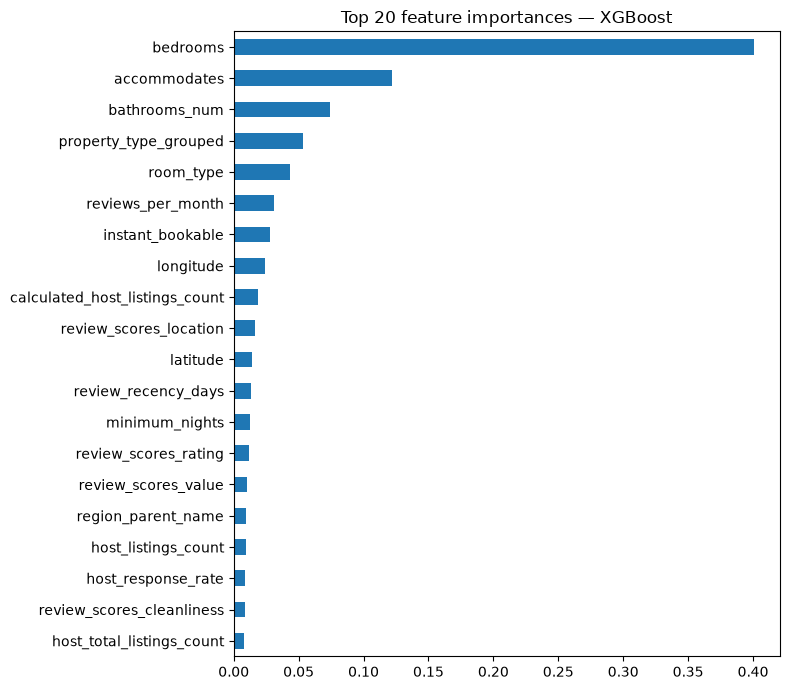


Top 20 features:
bedrooms                          0.400716
accommodates                      0.122267
bathrooms_num                     0.073940
property_type_grouped             0.053639
room_type                         0.042990
reviews_per_month                 0.030656
instant_bookable                  0.028303
longitude                         0.023887
calculated_host_listings_count    0.019069
review_scores_location            0.016590
latitude                          0.013719
review_recency_days               0.013628
minimum_nights                    0.012686
review_scores_rating              0.011611
review_scores_value               0.010487
region_parent_name                0.009446
host_listings_count               0.009360
host_response_rate                0.008636
review_scores_cleanliness         0.008394
host_total_listings_count         0.007805
dtype: float32


In [23]:
# Get feature names in the order the pipeline sees them
cat_names = CATEGORICAL_COLS
num_names = NUMERIC_COLS

# ColumnTransformer puts categorical first, then passthrough (numeric)
feature_names = cat_names + num_names

importances = xgb_model.named_steps['model'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

feat_imp.head(20).plot(kind='barh', figsize=(8, 7))
plt.title("Top 20 feature importances — XGBoost")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 20 features:")
print(feat_imp.head(20))

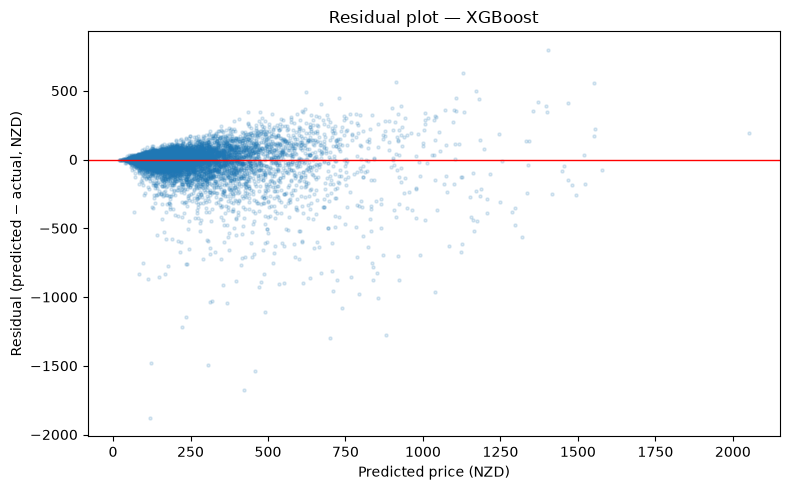

In [24]:
pred_log   = xgb_model.predict(X_test)
actual_log = y_test.values
residuals  = np.expm1(pred_log) - np.expm1(actual_log)

plt.figure(figsize=(8, 5))
plt.scatter(np.expm1(pred_log), residuals, alpha=0.15, s=5)
plt.axhline(0, color='red', linewidth=1)
plt.xlabel("Predicted price (NZD)")
plt.ylabel("Residual (predicted − actual, NZD)")
plt.title("Residual plot — XGBoost")
plt.tight_layout()
plt.show()

In [ ]:
BEST_MODEL = xgb_model

os.makedirs('../models', exist_ok=True)
joblib.dump(BEST_MODEL, '../models/price_model.pkl')
print("Pipeline saved to ../models/price_model.pkl")

# Quick smoke-test: reload and predict one row
loaded = joblib.load('../models/price_model.pkl')
sample = X_test.iloc[[0]]
pred   = np.expm1(loaded.predict(sample))[0]
actual = np.expm1(y_test.iloc[0])
print(f"Smoke-test — predicted: NZD {pred:.0f}   actual: NZD {actual:.0f}")

Pipeline saved to ../models/price_model.pkl
Smoke-test — predicted: NZD 137   actual: NZD 155
